<H1>Bayesian Linear Model Using Using TensorFlow Probability</H1>

In [65]:
import matplotlib.pyplot as plt
import numpy as np

In [66]:
import tensorflow as tf
import tensorflow_probability as tfp

print('TF version:', tf.__version__)
print('TFP version:', tfp.__version__)

TF version: 2.20.0
TFP version: 0.25.0


<H1>1) Data Generation</H1>

$\large\text{Create a training set that reprents the folowing linear function: }$<br>
$$\large y_{i}=2+3.25x_{i}+\epsilon_{i}\quad\quad\quad\text{ and }\epsilon\sim\mathcal{N}\left(0,\sigma^{2}I\right)$$

In [67]:
# Create and plot training data
# Set the desired slope
desired_slope = 3.25
# Set the desired intercept
desired_intercept = 2
# Set number of samples we want in our training data set
num_training_samples = 1000
x_train = np.linspace(-2, 2, num_training_samples)[:, np.newaxis]
# Append a column of ones to x_train for the intercept term
#x_train = np.hstack((np.ones_like(x_train), x_train))



x_train shape: (1000, 1)
y_train shape: (1000, 1)


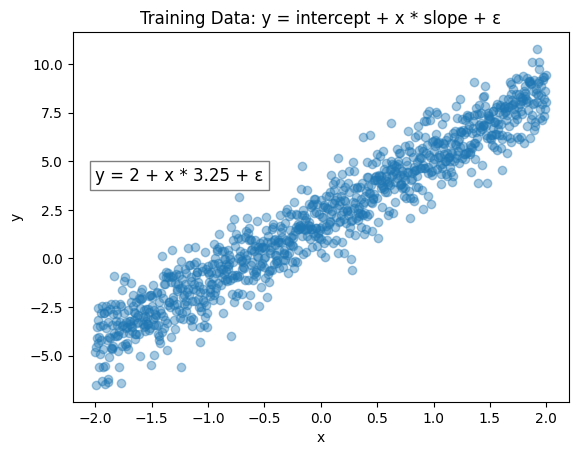

In [68]:
# Generate dependent variable y as a function of the training data x, the desired slope, and the desired intercept
#y_train = np.add(np.add(np.dot(x_train[:,1], desired_slope) ,desired_intercept), np.random.randn(num_training_samples))#[:, np.newaxis]
y_train = desired_intercept + x_train * desired_slope + np.random.randn(num_training_samples)[:, np.newaxis]
# Print the shape of x_train and y_train
print('x_train shape:', x_train.shape)
print('y_train shape:', y_train.shape)
# Plot the training data (ignoring the intercept term in each entry of x_train)
#plt.scatter(x_train[:,1], y_train, alpha=0.4)
plt.scatter(x_train, y_train, alpha=0.4)
plt.title('Training Data: y = intercept + x * slope + \u03B5')
plt.xlabel('x')
plt.ylabel('y')
plt.text(-2., 4, f'y = {desired_intercept} + x * {desired_slope} + \u03B5',
                       fontsize=12, bbox=dict(facecolor='white', alpha=0.5, edgecolor='black')) 
plt.show()


<H1>2) Configure the linear regression model</H1>

Let $n$ be the number of training samples and $m$ be the number of features in the training data.

$$\large\underset{\left(nx1\right)}{Y}=\begin{pmatrix}
y_{0} \\
y_{1} \\
\vdots \\
y_{n-1} \end{pmatrix}, 

\quad\underset{\left(nxm\right)}{X}=\left[\begin{matrix}
x_{0,0}=1 & x_{0,11} &\dots &x_{0,m-1} \\
x_{1,0}=1 & x_{1,1} &\dots &x_{1,m-1} \\
\vdots & \dots & \ddots & \vdots\\
x_{n-1,0}=1 & \dots & \dots &x_{N-1, m-1}
\end{matrix}\right],

\quad\underset{\left(Nx1\right)}{\epsilon}=\begin{pmatrix}
\epsilon_{0} \\
\epsilon_{1} \\
\vdots \\
\epsilon_{n-1} \end{pmatrix}
\text{where }\epsilon\sim\mathcal{N}\left(0, \sigma^{2}I\right)$$

$$\large\hat{Y}\sim\mathcal{N}(\hat{\beta} X, \hat{\sigma}^{2}I)$$


$P(Y_{i}=y_{i}|X_{i}=x_{i}, \beta=\hat{\beta}, \sigma=\hat{\sigma}^{2})$<br>

In [69]:
# Set the input shape
input_shape = x_train.shape[1]
print('Input shape:', input_shape)
# Create a dense Keras model along with a distribution layer that outputs a normal 
model = tf.keras.Sequential([
    tf.keras.layers.Dense(units=2, input_shape=(x_train.shape[1],), activation='linear'),
    tfp.layers.DistributionLambda(lambda t: tfp.distributions.Independent(tfp.distributions.Normal(loc=t[..., :1], scale=tf.math.softplus(t[..., 1:]))))
])

Input shape: 1


$\large\quad\text{Define the loss function}$<br>

Minimizing the negative log-likelihood of the learned distribution 

In [70]:
# Define the negative log likelihood cost function
def nll(x_train, distribution):
    return -tf.reduce_sum(distribution.log_prob(x_train))

<H1>3) Learn estimates for the model parameter(s)</H1>

In [71]:
# Instantiate an optimizer
optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.005)
model.compile(loss=nll, optimizer=optimizer)
model.summary()
model.fit(x_train, y_train, epochs=500, verbose=False)

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 2)                 4         
                                                                 
 distribution_lambda_7 (Dis  ((None, 1),               0         
 tributionLambda)             (None, 1))                         
                                                                 
Total params: 4 (16.00 Byte)
Trainable params: 4 (16.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


<H1>4) Make predictions on the training data.</H1>

In [72]:
# Make predictions.
yhat = model(x_train)
yhat_mean = yhat.mean()
yhat_std = yhat.stddev()

<H1>5) Compute trained prediction model metrics.</H1>

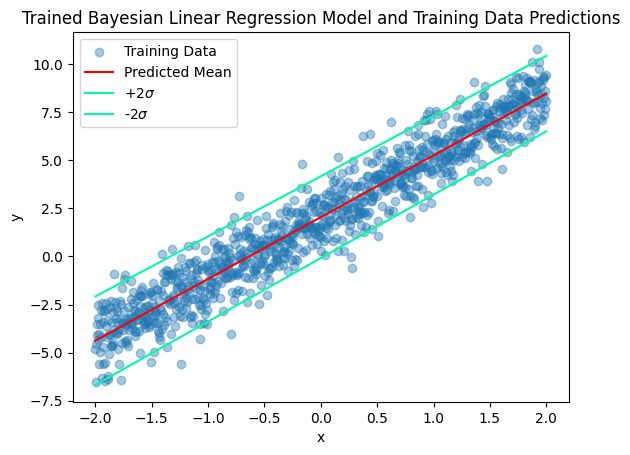

In [73]:
# Plot the training data and the model predictions
plt.scatter(x_train, y_train, alpha=0.4, label='Training Data')
plt.plot(x_train, yhat_mean, color='red', label='Predicted Mean')
plt.plot(x_train, yhat_mean+2*yhat_std, color='#03fca1', label=r'+2$\sigma$')
plt.plot(x_train, yhat_mean-2*yhat_std, color='#03fca1', label=r'-2$\sigma$')
plt.title('Trained Bayesian Linear Regression Model and Training Data Predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()



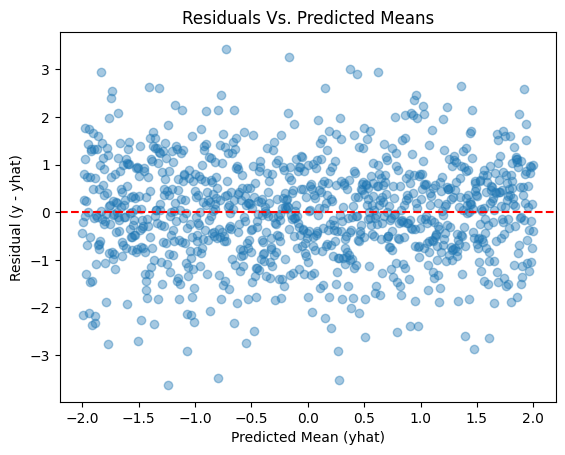

In [74]:
# Plot the residuals
residuals = y_train - yhat_mean
plt.scatter(x_train, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Vs. Predicted Means')
plt.xlabel('Predicted Mean (yhat)')
plt.ylabel('Residual (y - yhat)')
plt.show()

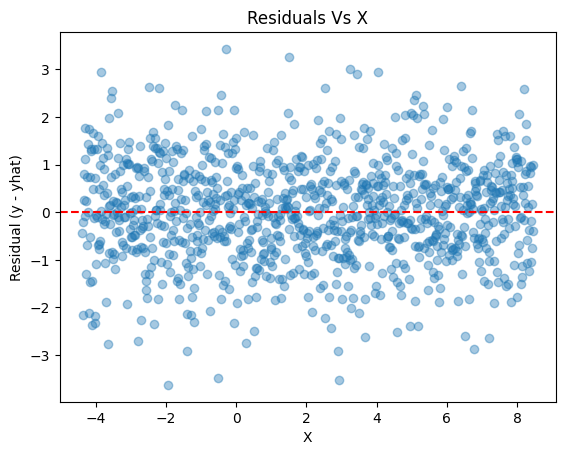

In [75]:
# Scatter Plot residuals vs predicitons
# Plot the residuals
residuals = y_train - yhat_mean
plt.scatter(yhat_mean, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Vs X')
plt.xlabel('X')
plt.ylabel('Residual (y - yhat)')
plt.show()

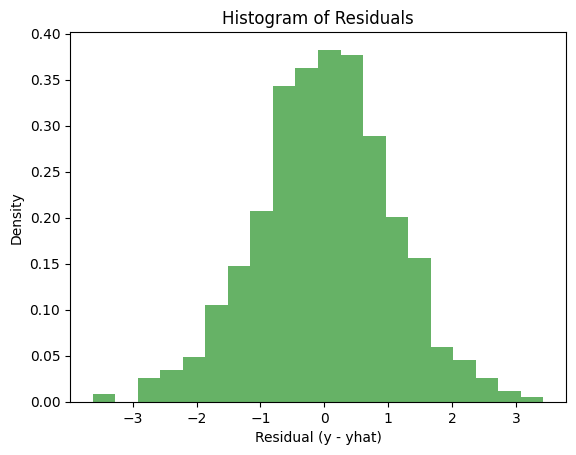

In [76]:
# Plot historgram of residuals
plt.hist(residuals, bins=20, density=True, alpha=0.6, color='green')
plt.title('Histogram of Residuals')
plt.xlabel('Residual (y - yhat)')
plt.ylabel('Density')
plt.show()  

<H1>References</H1>

1. Kutner M., Nachtsheim C., Neter J., "Applied Linear Regression Models", McGraw3-Hill Irwin, 4th ed, 2004.
2. Gelman A., Carlin J., Stern H., Dunson D., Vehtari A., Rubin D., "Bayesian Data Analysis", CRC Press, Boca Raton FL, 3rd ed., 2014.